In [135]:
import numpy as np
import matplotlib.pyplot as plt

In [136]:
params = {
        "RS": (0.02, 0.2, -65, 2),
        "IB": (0.02, 0.2, -55, 4),
        "CH": (0.02, 0.2, -50, 2),
        "FS": (0.1, 0.2, -65, 2),
        "TC": (0.02, 0.25, -65, 0.05),
        "RZ": (0.1, 0.26, -65, 0.05),
        "LTS": (0.02, 0.25, -65, 2)
    }

In [137]:
def I_input(t):
    if 10 < t < 40:
        return 10
    
    return 0

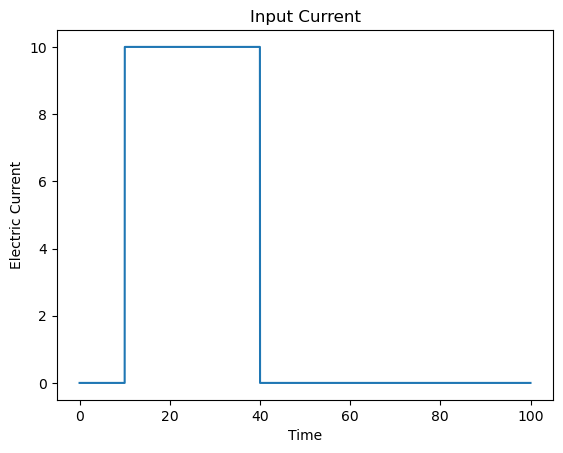

In [138]:
step = 0.01
t_start = 0
t_end = 100

time = np.arange(t_start, t_end, step)

I_values = []

for t in time:
    I_values.append(I_input(t))

plt.plot(time, I_values)
plt.title("Input Current")
plt.xlabel("Time")
plt.ylabel("Electric Current")
plt.show()

In [139]:
def dv_dt(v, u, I, a, b, c, d):
    return 0.04*v**2 + 5*v + 140 - u + I

def du_dt(v, u, a, b):
    return a*(v*b - u)

In [140]:
def izikevich_model(a, b, c, d):
    v = -65
    u = b*v
    
    v_vector = []


    for dt in time:
        I = I_input(dt)
        dV = dv_dt(v,u,I, a, b, c, d)
        dU = du_dt(v,u, a, b)

        v = v + step*dV
        u = u + step*dU

        if v >= 30:
            v = c
            u += d

        v_vector.append(v)

    plt.plot(time, v_vector)
    plt.title(f"Neuron with params a={a}, b={b}, c={c}, d={d}")
    plt.xlabel("Time")
    plt.ylabel("Membrane Potential (v)")
    plt.show()
    
    return v_vector

In [141]:
def layer(n, params):
    outputs = []
    for neuron_type in params.values():
        a, b, c, d = neuron_type
        output = izikevich_model(a, b, c, d)
        outputs.append(output)
    return outputs

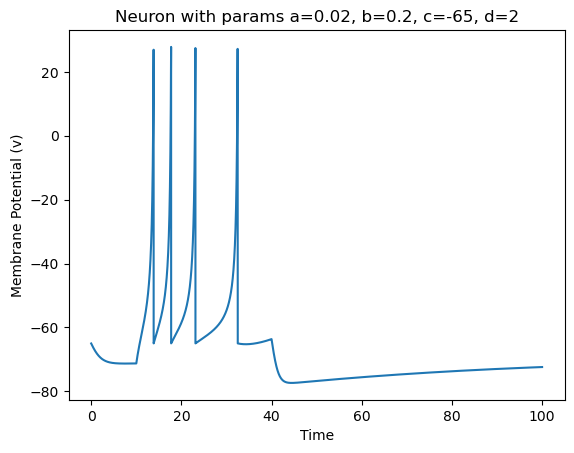

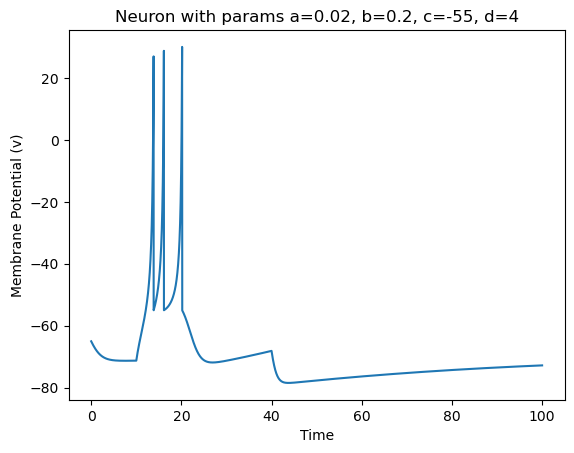

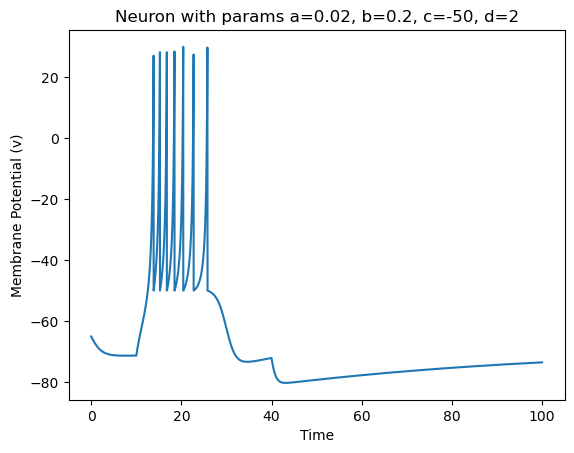

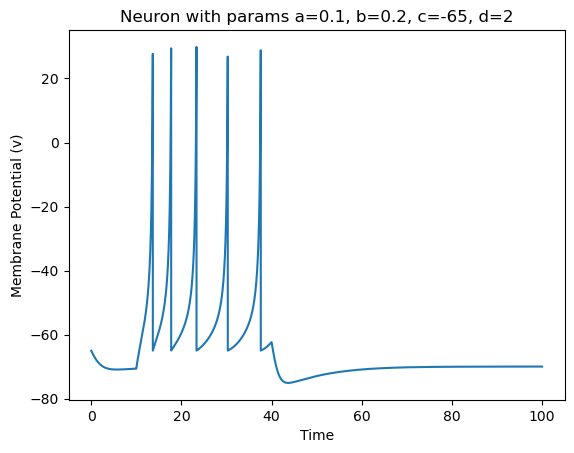

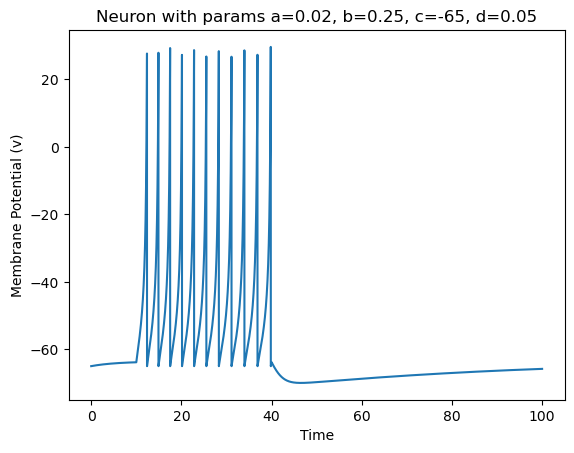

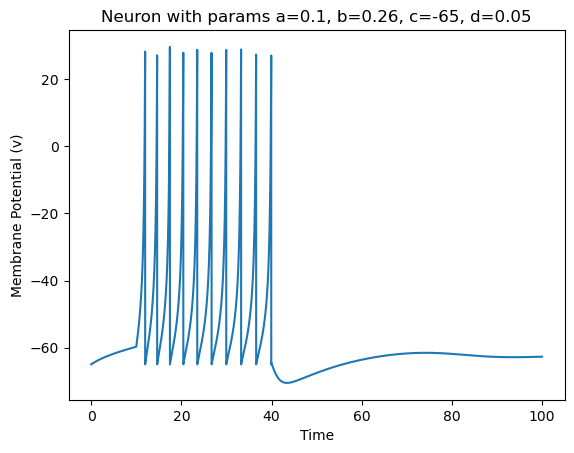

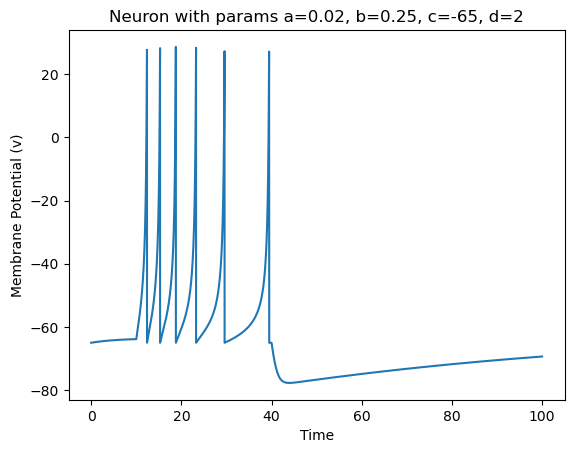

[[-65.03,
  -65.05993964,
  -65.08981831161582,
  -65.11963541208749,
  -65.149390344317,
  -65.179082516905,
  -65.20871134418648,
  -65.23827624626536,
  -65.26777664904802,
  -65.2972119842758,
  -65.3265816895565,
  -65.35588520839465,
  -65.38512199022092,
  -65.41429149042034,
  -65.44339317035954,
  -65.4724264974129,
  -65.50139094498762,
  -65.53028599254783,
  -65.55911112563756,
  -65.58786583590266,
  -65.61654962111179,
  -65.64516198517617,
  -65.67370243816852,
  -65.70217049634074,
  -65.73056568214074,
  -65.75888752422811,
  -65.78713555748885,
  -65.815309323049,
  -65.84340836828731,
  -65.87143224684694,
  -65.89938051864596,
  -65.92725274988709,
  -65.95504851306632,
  -65.98276738698048,
  -66.01040895673397,
  -66.03797281374437,
  -66.06545855574721,
  -66.0928657867996,
  -66.1201941172831,
  -66.14744316390549,
  -66.17461254970162,
  -66.2017019040334,
  -66.22871086258874,
  -66.25563906737966,
  -66.28248616673945,
  -66.30925181531889,
  -66.335935674081

In [142]:
layer(5, params)